# Minimal noisy-source Bayesian reasoning with Qwen3.5-4B

This notebook builds noisy channel decoding experiment. It generates complete scripted conversations between Qwen (Q) and a programmatic source (A), computes the exact Bayesian posterior, and evaluates Qwen with forced-choice probes.

## Experimental contract

- The secret $s$ is uniformly distributed over $\{1,\ldots,N\}$.
- For a membership proposition $q(s)$, Source A reports its truth value with probability $r$ and the opposite value with probability $1-r$. Answers are conditionally independent.
- Qwen never chooses a question. The transcript generator inserts every question as a prior assistant turn using one fixed template.
- Three scripted policies are supported: adaptive binary search, random subsets without answer memory, and random subsets with hard elimination.
- Qwen is never asked for all $N$ probabilities. It chooses A, B, or C on candidate and half-domain comparisons.
- The normative posterior is computed with exact rational arithmetic. Each semantic answer is assigned to A, B, and C equally often, so reported accuracy is counterbalanced against label and display-position preferences.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import random
from dataclasses import asdict, dataclass
from fractions import Fraction
from itertools import permutations
from pathlib import Path
from typing import Literal, Sequence

import matplotlib.pyplot as plt

# The issue with policies for question asking is that they must be stateless from the previous questions
# stateful question asking policies induce a dependency between questions, thus answers
#PolicyName = Literal["binary_search", "random_memoryless", "random_elimination"]
PolicyName = Literal["random_memoryless"]
Answer = Literal["YES", "NO"]
Label = Literal["A", "B", "C"]
SemanticChoice = Literal["left", "right", "tie"]
LABELS: tuple[Label, ...] = ("A", "B", "C")
SEMANTIC_CHOICES: tuple[SemanticChoice, ...] = ("left", "right", "tie")
LABEL_ASSIGNMENTS = tuple(permutations(SEMANTIC_CHOICES))


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the MATS repository.")


REPO_ROOT = find_repo_root()
MODEL_PATH = REPO_ROOT / "models" / "Qwen--Qwen3.5-4B"
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "minimal_noisy_source"

N = 8
SECRETS = tuple(range(1, N+1)) # Change to tuple(range(1, N + 1)) for a balanced secret sweep.
NUM_TURNS = 3
RANDOM_MEMORYLESS_MEMBERSHIP_KEYS: int | tuple[int, ...] = 4
RANDOM_MEMORYLESS_SORT_SUBSET = True
RANDOM_MEMORYLESS_DRAW_WITH_REPLACEMENT = False
RELIABILITIES = tuple(Fraction(x, 10) for x in (10, 9, 7, 5, 3, 1, 0))
POLICIES: tuple[PolicyName, ...] = (
    #"binary_search",
    "random_memoryless",
    #"random_elimination",
)
CANDIDATE_PAIR = (2, 7)
NUM_REPEATS = 5
BASE_SEED = 20260825
COUPLE_NOISE_ACROSS_RELIABILITIES = True

assert N >= 2
assert isinstance(RANDOM_MEMORYLESS_MEMBERSHIP_KEYS, (int, tuple))
if isinstance(RANDOM_MEMORYLESS_MEMBERSHIP_KEYS, tuple):
    assert len(RANDOM_MEMORYLESS_MEMBERSHIP_KEYS) == NUM_TURNS
    random_memoryless_draw_sizes = RANDOM_MEMORYLESS_MEMBERSHIP_KEYS
else:
    random_memoryless_draw_sizes = (RANDOM_MEMORYLESS_MEMBERSHIP_KEYS,) * NUM_TURNS
assert all(type(draw_size) is int for draw_size in random_memoryless_draw_sizes)
assert all(1 <= draw_size <= N for draw_size in random_memoryless_draw_sizes)
assert type(RANDOM_MEMORYLESS_SORT_SUBSET) is bool
assert type(RANDOM_MEMORYLESS_DRAW_WITH_REPLACEMENT) is bool
assert all(1 <= s <= N for s in SECRETS)
assert all(Fraction(0) <= r <= Fraction(1) for r in RELIABILITIES)
assert len(set(CANDIDATE_PAIR)) == 2 and all(1 <= x <= N for x in CANDIDATE_PAIR)

## Transcript and probe types

The secret and channel coin flips are retained as evaluation metadata but are never shown to Qwen. The system-prompt wording and turn templates are identical across examples except for the declared $N$ and $r$.

In [2]:
@dataclass(frozen=True)
class Observation:
    turn: int
    subset: tuple[int, ...]
    answer: Answer
    truthful_answer: Answer
    channel_was_correct: bool


@dataclass(frozen=True)
class Probe:
    kind: Literal["candidate", "half"]
    question: str
    option_texts: tuple[str, str, str]  # left, right, tie
    normative_semantic_choice: SemanticChoice
    option_probabilities: tuple[Fraction, Fraction]


@dataclass(frozen=True)
class TranscriptExample:
    example_id: str
    n: int
    secret: int
    reliability: Fraction
    policy: PolicyName
    repeat: int
    observations: tuple[Observation, ...]
    posterior: tuple[Fraction, ...]
    messages: tuple[dict[str, str], ...]
    probes: tuple[Probe, ...]

# TODO: removed the line "All membership questions in the conversation were fixed by the experiment program. Do not choose or request new questions." this seems to provide too much information
# about the experiment setup
SYSTEM_TEMPLATE = """You are in a hidden-secret inference game. You are talking to SOURCE.
The secret number s was drawn uniformly from the integers 1 through {n}.
SOURCE knows s. For each membership question, the proposition is either true or false.
SOURCE reports the proposition's true YES/NO answer with probability r = {reliability}, and reports the opposite answer with probability 1-r = {error_rate}.
SOURCE's channel outcomes are independent between questions conditional on s. The value of r may be below 0.5.
Treat each message beginning with 'SOURCE answer:' as an observation from the stated noisy channel.
At the final TEST, compare the two posterior probabilities requested. Reply with exactly A, B, or C and no other text."""


def format_set(values: Sequence[int]) -> str:
    return "{" + ", ".join(map(str, values)) + "}"


def system_message(n: int, reliability: Fraction) -> dict[str, str]:
    return {
        "role": "system",
        "content": SYSTEM_TEMPLATE.format(
            n=n,
            reliability=float(reliability),
            error_rate=float(1 - reliability),
        ),
    }


def question_message(turn: int, subset: Sequence[int]) -> dict[str, str]:
    return {
        "role": "assistant",
        "content": (
            f"Question {turn}: Is the secret in {format_set(subset)}? "
            "Answer YES or NO."
        ),
    }


def answer_message(answer: Answer) -> dict[str, str]:
    return {"role": "user", "content": f"SOURCE answer: {answer}."}

## Scripted question policies and noisy SOURCE

`binary_search` and `random_elimination` hard-filter a private policy state using observed answers. This state only selects later scripted questions; it is not used for the normative posterior. If a hard search reaches one candidate before all configured turns are used, a new search round begins over the full domain. `random_memoryless` always samples from the full domain and never reads previous answers.

In [3]:
def stable_seed(base_seed: int, *parts: object) -> int:
    payload = "|".join(map(str, (base_seed, *parts))).encode()
    return int.from_bytes(hashlib.blake2b(payload, digest_size=8).digest(), "big")


def policy_id_tag(
    policy: PolicyName,
    random_memoryless_membership_keys: int | tuple[int, ...],
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> str:
    if policy != "random_memoryless":
        return policy
    keys_tag = (
        str(random_memoryless_membership_keys)
        if isinstance(random_memoryless_membership_keys, int)
        else "-".join(map(str, random_memoryless_membership_keys))
    )
    sort_tag = "sorted" if random_memoryless_sort_subset else "unsorted"
    replacement_tag = (
        "with_replacement"
        if random_memoryless_draw_with_replacement
        else "without_replacement"
    )
    return f"{policy}_keys{keys_tag}_{sort_tag}_{replacement_tag}"


def choose_subset(
    policy: PolicyName,
    domain: tuple[int, ...],
    active: tuple[int, ...],
    rng: random.Random,
    random_memoryless_subset_size: int,
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> tuple[tuple[int, ...], tuple[int, ...]]:
    if policy == "random_memoryless":
        scope = domain
        subset_size = random_memoryless_subset_size
    else:
        scope = active if len(active) >= 2 else domain
        subset_size = max(1, len(scope) // 2)
    if policy == "binary_search":
        subset = scope[:subset_size]
    elif policy == "random_memoryless":
        draws = (
            rng.choices(scope, k=subset_size)
            if random_memoryless_draw_with_replacement
            else rng.sample(scope, k=subset_size)
        )
        subset = tuple(sorted(draws) if random_memoryless_sort_subset else draws)
    else:
        subset = tuple(sorted(rng.sample(scope, k=subset_size)))

    assert 0 < len(subset) <= len(scope)
    return subset, scope


def source_answer(
    secret: int, subset: Sequence[int], reliability: Fraction, rng: random.Random
) -> tuple[Answer, Answer, bool]:
    truth: Answer = "YES" if secret in subset else "NO"
    channel_was_correct = rng.random() < float(reliability)
    observed: Answer = truth if channel_was_correct else ("NO" if truth == "YES" else "YES")
    return observed, truth, channel_was_correct


def update_policy_state(
    policy: PolicyName,
    scope: tuple[int, ...],
    subset: tuple[int, ...],
    answer: Answer,
) -> tuple[int, ...]:
    if policy == "random_memoryless":
        return scope
    selected = set(subset)
    survivors = selected if answer == "YES" else set(scope) - selected
    return tuple(x for x in scope if x in survivors)


def generate_observations(
    *,
    n: int,
    secret: int,
    reliability: Fraction,
    policy: PolicyName,
    num_turns: int,
    repeat: int,
    base_seed: int,
    couple_noise: bool,
    random_memoryless_membership_keys: int | tuple[int, ...],
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> tuple[Observation, ...]:
    domain = tuple(range(1, n + 1))
    active = domain
    question_rng = random.Random(stable_seed(base_seed, "questions", policy, repeat))
    noise_parts: tuple[object, ...] = ("channel", policy, secret, repeat)
    if not couple_noise:
        noise_parts += (reliability.numerator, reliability.denominator)
    channel_rng = random.Random(stable_seed(base_seed, *noise_parts))

    observations: list[Observation] = []
    for turn in range(1, num_turns + 1):
        random_memoryless_subset_size = (
            random_memoryless_membership_keys
            if isinstance(random_memoryless_membership_keys, int)
            else random_memoryless_membership_keys[turn - 1]
        )
        subset, scope = choose_subset(
            policy,
            domain,
            active,
            question_rng,
            random_memoryless_subset_size,
            random_memoryless_sort_subset,
            random_memoryless_draw_with_replacement,
        )
        answer, truth, was_correct = source_answer(secret, subset, reliability, channel_rng)
        observations.append(
            Observation(
                turn=turn,
                subset=subset,
                answer=answer,
                truthful_answer=truth,
                channel_was_correct=was_correct,
            )
        )
        active = update_policy_state(policy, scope, subset, answer)

    return tuple(observations)

## Exact Bayesian posterior

For candidate $x$ and observation $(Q_t,a_t)$, the likelihood is $r$ when $a_t$ equals $[x\in Q_t]$ and $1-r$ otherwise. The function below multiplies these likelihoods into a uniform prior and normalizes using `Fraction`, so the reference answer has no floating-point ambiguity.

In [4]:
def exact_posterior(
    n: int, observations: Sequence[Observation], reliability: Fraction
) -> tuple[Fraction, ...]:
    weights: list[Fraction] = []
    for candidate in range(1, n + 1):
        weight = Fraction(1, n)
        for obs in observations:
            proposition = candidate in obs.subset
            reported_yes = obs.answer == "YES"
            likelihood = reliability if proposition == reported_yes else 1 - reliability
            weight *= likelihood
        weights.append(weight)

    evidence = sum(weights, start=Fraction(0))
    if evidence == 0:
        raise ValueError("Observations have zero probability under this channel model.")
    posterior = tuple(weight / evidence for weight in weights)
    assert sum(posterior, start=Fraction(0)) == 1
    return posterior


def compare(left: Fraction, right: Fraction) -> SemanticChoice:
    if left > right:
        return "left"
    if right > left:
        return "right"
    return "tie"


def render_probe(
    probe: Probe, semantics_by_label: Sequence[SemanticChoice]
) -> str:
    if set(semantics_by_label) != set(SEMANTIC_CHOICES):
        raise ValueError("Each label assignment must contain left, right, and tie once.")
    lines = [probe.question]
    for label, semantic in zip(LABELS, semantics_by_label):
        option_index = SEMANTIC_CHOICES.index(semantic)
        lines.append(f"{label}: {probe.option_texts[option_index]}")
    lines.append("Reply with exactly A, B, or C.")
    return "\n".join(lines)


def make_probes(
    posterior: tuple[Fraction, ...], candidate_pair: tuple[int, int]
) -> tuple[Probe, Probe]:
    left_candidate, right_candidate = candidate_pair
    left_probability = posterior[left_candidate - 1]
    right_probability = posterior[right_candidate - 1]
    candidate_probe = Probe(
        kind="candidate",
        question="TEST — Given all evidence, which candidate has greater posterior probability?",
        option_texts=(
            str(left_candidate),
            str(right_candidate),
            "They have equal posterior probability.",
        ),
        normative_semantic_choice=compare(left_probability, right_probability),
        option_probabilities=(left_probability, right_probability),
    )

    midpoint = len(posterior) // 2
    first_half = sum(posterior[:midpoint], start=Fraction(0))
    second_half = sum(posterior[midpoint:], start=Fraction(0))
    first_values = tuple(range(1, midpoint + 1))
    second_values = tuple(range(midpoint + 1, len(posterior) + 1))
    half_probe = Probe(
        kind="half",
        question="TEST — Given all evidence, which set has greater posterior probability?",
        option_texts=(
            format_set(first_values),
            format_set(second_values),
            "The two sets have equal posterior probability.",
        ),
        normative_semantic_choice=compare(first_half, second_half),
        option_probabilities=(first_half, second_half),
    )
    return candidate_probe, half_probe

## Generate complete transcripts

The assistant turns below are fixed questions inserted by the generator. Qwen only receives the completed history and the final test prompt. Coupled channel random numbers make the reliability sweep easier to compare: for a given secret, policy, repeat, and turn, the same uniform draw is judged against each $r$.

In [5]:
def build_example(
    *,
    n: int,
    secret: int,
    reliability: Fraction,
    policy: PolicyName,
    num_turns: int,
    repeat: int,
    base_seed: int,
    candidate_pair: tuple[int, int],
    couple_noise: bool,
    random_memoryless_membership_keys: int | tuple[int, ...],
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> TranscriptExample:
    observations = generate_observations(
        n=n,
        secret=secret,
        reliability=reliability,
        policy=policy,
        num_turns=num_turns,
        repeat=repeat,
        base_seed=base_seed,
        couple_noise=couple_noise,
        random_memoryless_membership_keys=random_memoryless_membership_keys,
        random_memoryless_sort_subset=random_memoryless_sort_subset,
        random_memoryless_draw_with_replacement=random_memoryless_draw_with_replacement,
    )
    posterior = exact_posterior(n, observations, reliability)
    messages: list[dict[str, str]] = [system_message(n, reliability)]
    for observation in observations:
        messages.append(question_message(observation.turn, observation.subset))
        messages.append(answer_message(observation.answer))

    reliability_tag = f"{reliability.numerator}-{reliability.denominator}"
    policy_tag = policy_id_tag(
        policy,
        random_memoryless_membership_keys,
        random_memoryless_sort_subset,
        random_memoryless_draw_with_replacement,
    )
    example_id = f"n{n}_s{secret}_{policy_tag}_r{reliability_tag}_rep{repeat}"
    return TranscriptExample(
        example_id=example_id,
        n=n,
        secret=secret,
        reliability=reliability,
        policy=policy,
        repeat=repeat,
        observations=observations,
        posterior=posterior,
        messages=tuple(messages),
        probes=make_probes(posterior, candidate_pair),
    )


examples = [
    build_example(
        n=N,
        secret=secret,
        reliability=reliability,
        policy=policy,
        num_turns=NUM_TURNS,
        repeat=repeat,
        base_seed=BASE_SEED,
        candidate_pair=CANDIDATE_PAIR,
        couple_noise=COUPLE_NOISE_ACROSS_RELIABILITIES,
        random_memoryless_membership_keys=RANDOM_MEMORYLESS_MEMBERSHIP_KEYS,
        random_memoryless_sort_subset=RANDOM_MEMORYLESS_SORT_SUBSET,
        random_memoryless_draw_with_replacement=RANDOM_MEMORYLESS_DRAW_WITH_REPLACEMENT,
    )
    for secret in SECRETS
    for policy in POLICIES
    for reliability in RELIABILITIES
    for repeat in range(NUM_REPEATS)
]

assert len({example.example_id for example in examples}) == len(examples)
assert all(sum(example.posterior, start=Fraction(0)) == 1 for example in examples)
assert all(
    probability == Fraction(1, N)
    for example in examples
    if example.reliability == Fraction(1, 2)
    for probability in example.posterior
)
print(f"Generated {len(examples)} examples and {sum(len(x.probes) for x in examples)} probes.")

Generated 280 examples and 560 probes.


In [7]:
def print_example(example: TranscriptExample) -> None:
    print(example.example_id)
    print("\nTRANSCRIPT (without a final probe)")
    for message in example.messages:
        print(f"\n[{message['role'].upper()}]\n{message['content']}")
    print("\nEXACT POSTERIOR")
    for candidate, probability in enumerate(example.posterior, start=1):
        print(f"P(s={candidate} | evidence) = {probability} = {float(probability):.6f}")
    print("\nPROBES")
    for probe in example.probes:
        print(f"{probe.kind}: normative={probe.normative_semantic_choice}")
        print(render_probe(probe, SEMANTIC_CHOICES))


# Preview a critical trustworthy-channel example before loading the model.
preview = next(
    example
    for example in examples
    if example.reliability == Fraction(9, 10)
)
print_example(preview)

n8_s1_random_memoryless_r9-10_rep0

TRANSCRIPT (without a final probe)

[SYSTEM]
You are in a hidden-secret inference game. You are talking to SOURCE.
The secret number s was drawn uniformly from the integers 1 through 8.
SOURCE knows s. For each membership question, the proposition is either true or false.
SOURCE reports the proposition's true YES/NO answer with probability r = 0.9, and reports the opposite answer with probability 1-r = 0.1.
SOURCE's channel outcomes are independent between questions conditional on s. The value of r may be below 0.5.
Treat each message beginning with 'SOURCE answer:' as an observation from the stated noisy channel.
At the final TEST, compare the two posterior probabilities requested. Reply with exactly A, B, or C and no other text.

[ASSISTANT]
Question 1: Is the secret in {2, 5, 6, 7}? Answer YES or NO.

[USER]
SOURCE answer: NO.

[ASSISTANT]
Question 2: Is the secret in {1, 4, 6, 7}? Answer YES or NO.

[USER]
SOURCE answer: YES.

[ASSISTANT]
Questio

## Save generated transcripts

This JSONL artifact contains the full messages, hidden experimental metadata, exact posterior strings, and both normative probes. It is sufficient to rerun model evaluation without regenerating the source conversations.

In [7]:
def fraction_string(value: Fraction) -> str:
    return f"{value.numerator}/{value.denominator}"


def serialize_example(example: TranscriptExample) -> dict[str, object]:
    return {
        "example_id": example.example_id,
        "n": example.n,
        "secret": example.secret,
        "reliability": fraction_string(example.reliability),
        "policy": example.policy,
        "repeat": example.repeat,
        "observations": [asdict(observation) for observation in example.observations],
        "posterior_exact": [fraction_string(p) for p in example.posterior],
        "posterior_float": [float(p) for p in example.posterior],
        "messages": list(example.messages),
        "probes": [
            {
                "kind": probe.kind,
                "canonical_prompt": render_probe(probe, SEMANTIC_CHOICES),
                "question": probe.question,
                "semantic_options": dict(zip(SEMANTIC_CHOICES, probe.option_texts)),
                "normative_semantic_choice": probe.normative_semantic_choice,
                "option_probabilities_exact": [
                    fraction_string(p) for p in probe.option_probabilities
                ],
            }
            for probe in example.probes
        ],
    }


ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
transcript_path = ARTIFACT_DIR / "transcripts.jsonl"
with transcript_path.open("w", encoding="utf-8") as handle:
    for example in examples:
        handle.write(json.dumps(serialize_example(example)) + "\n")
print(f"Saved {len(examples)} examples to {transcript_path}")

Saved 840 examples to /workspace/MATS/artifacts/minimal_noisy_source/transcripts.jsonl


## Load Qwen3.5-4B locally — run only when ready

The checkpoint is multimodal, so this uses `Qwen3_5ForConditionalGeneration` and `AutoProcessor` even though the experiment is text-only. The chat template is called with thinking disabled to keep the measured continuation constrained to A/B/C. On Apple Silicon, the notebook selects MPS and float16; on CUDA it prefers bfloat16 when supported. CPU fallback is possible but slow.

The local Qwen model card requires a recent Transformers build with Qwen3.5 support. The repository lockfile currently resolves a compatible release.

In [8]:
import torch
from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration

assert MODEL_PATH.exists(), f"Missing local checkpoint: {MODEL_PATH}"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    MODEL_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    MODEL_DTYPE = torch.float16
else:
    DEVICE = torch.device("cpu")
    MODEL_DTYPE = torch.bfloat16

processor = AutoProcessor.from_pretrained(MODEL_PATH, local_files_only=True)
model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    dtype=MODEL_DTYPE,
    local_files_only=True,
)
model.to(DEVICE)
model.eval()
print(f"Loaded {MODEL_PATH.name} on {DEVICE} with dtype={MODEL_DTYPE}.")

/workspace/MATS/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 723/723 [00:00<00:00, 5164.49it/s]


Loaded Qwen--Qwen3.5-4B on cuda with dtype=torch.bfloat16.


## Label-counterbalanced forced-choice scoring

A language model can prefer the token `A`, `B`, or `C`, or a displayed position, independently of the option's meaning. A single labeling would confound Bayesian reasoning with that superficial preference. For every probe, this notebook therefore evaluates all $3!=6$ assignments of the semantic answers `left`, `right`, and `tie` to labels A/B/C. Each semantic answer appears twice under every label and twice in every displayed position.

Within each permutation, the next-token logits are normalized over A/B/C and mapped back into semantic space. The notebook averages these relative semantic log scores across permutations, makes its primary prediction from that aggregate, and compares the semantic prediction—not a label—to the exact Bayesian target. This cancels a stable additive label/position bias and exposes more complicated sensitivity through the permutation-consistency metric.

Permutation consistency is the fraction of the six individually mapped predictions that agree with the counterbalanced aggregate prediction. A value of 1 means the model's semantic decision survives every relabeling; a low value warns that even a correct aggregate answer is presentation-sensitive. Counterbalancing cannot remove arbitrary interactions between wording and reasoning, so both aggregate accuracy and consistency are reported.

In [9]:
CHOICE_TEXT: dict[Label, str] = {"A": "A", "B": "B", "C": "C"}
DEFAULT_INFERENCE_BATCH_SIZE = 24 if DEVICE.type == "cuda" else 12
INFERENCE_BATCH_SIZE = int(
    os.environ.get("INFERENCE_BATCH_SIZE", DEFAULT_INFERENCE_BATCH_SIZE)
)
if INFERENCE_BATCH_SIZE < len(LABEL_ASSIGNMENTS) or INFERENCE_BATCH_SIZE % len(LABEL_ASSIGNMENTS):
    raise ValueError(
        f"INFERENCE_BATCH_SIZE must be a positive multiple of {len(LABEL_ASSIGNMENTS)}."
    )
PROBES_PER_BATCH = INFERENCE_BATCH_SIZE // len(LABEL_ASSIGNMENTS)
# With logits_to_keep=1, every real prompt must end at the final padded position.
processor.tokenizer.padding_side = "left"
print(
    f"Scoring {PROBES_PER_BATCH} probes / {INFERENCE_BATCH_SIZE} prompts per batch."
)

LABEL_TOKEN_IDS: dict[Label, int] = {}
for label, text in CHOICE_TEXT.items():
    token_ids = processor.tokenizer(text, add_special_tokens=False)["input_ids"]
    if len(token_ids) != 1:
        raise ValueError(f"Counterbalancing requires a single token for {label!r}; got {token_ids}.")
    LABEL_TOKEN_IDS[label] = token_ids[0]


def messages_for_probe(
    example: TranscriptExample,
    probe: Probe,
    semantics_by_label: Sequence[SemanticChoice],
) -> list[dict[str, str]]:
    prompt = render_probe(probe, semantics_by_label)
    return [*example.messages, {"role": "user", "content": prompt}]


def relative_log_scores(log_scores: dict[str, float]) -> dict[str, float]:
    max_score = max(log_scores.values())
    log_normalizer = max_score + math.log(
        sum(math.exp(score - max_score) for score in log_scores.values())
    )
    return {key: score - log_normalizer for key, score in log_scores.items()}


def score_labels_batch(
    messages_batch: Sequence[Sequence[dict[str, str]]],
) -> list[dict[Label, float]]:
    if not messages_batch:
        return []
    prompt = processor.apply_chat_template(
        [list(messages) for messages in messages_batch],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=False,
        processor_kwargs={"padding": True},
    )
    input_ids = prompt["input_ids"].to(DEVICE)
    attention_mask = prompt["attention_mask"].to(DEVICE)
    label_token_ids = torch.tensor(
        [LABEL_TOKEN_IDS[label] for label in LABELS],
        device=DEVICE,
    )

    with torch.inference_mode():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=False,
            logits_to_keep=1,
        )
        label_log_probs = (
            outputs.logits[:, -1, :]
            .float()
            .log_softmax(dim=-1)
            .index_select(dim=-1, index=label_token_ids)
            .cpu()
        )
    return [
        {label: float(value) for label, value in zip(LABELS, row.tolist())}
        for row in label_log_probs
    ]


def aggregate_probe_scores(
    example: TranscriptExample,
    probe: Probe,
    permutation_label_log_scores: Sequence[dict[Label, float]],
) -> dict[str, object]:
    if len(permutation_label_log_scores) != len(LABEL_ASSIGNMENTS):
        raise ValueError("Expected one score dictionary per label assignment.")
    permutation_records: list[dict[str, object]] = []
    semantic_log_values: dict[SemanticChoice, list[float]] = {
        semantic: [] for semantic in SEMANTIC_CHOICES
    }

    for semantics_by_label, label_log_scores in zip(
        LABEL_ASSIGNMENTS, permutation_label_log_scores
    ):
        label_relative_logs = relative_log_scores(label_log_scores)
        label_probabilities = {
            label: math.exp(log_score) for label, log_score in label_relative_logs.items()
        }
        label_to_semantic = dict(zip(LABELS, semantics_by_label))
        predicted_label: Label = max(
            label_log_scores, key=label_log_scores.get
        )  # type: ignore[arg-type]
        predicted_semantic = label_to_semantic[predicted_label]

        for label, semantic in label_to_semantic.items():
            semantic_log_values[semantic].append(label_relative_logs[label])

        permutation_records.append(
            {
                "semantic_by_label": label_to_semantic,
                "label_log_scores": label_log_scores,
                "label_probabilities": label_probabilities,
                "predicted_label": predicted_label,
                "predicted_semantic_choice": predicted_semantic,
            }
        )

    aggregate_semantic_log_scores: dict[str, float] = {
        semantic: sum(values) / len(values)
        for semantic, values in semantic_log_values.items()
    }
    aggregate_relative_logs = relative_log_scores(aggregate_semantic_log_scores)
    counterbalanced_probabilities = {
        semantic: math.exp(log_score)
        for semantic, log_score in aggregate_relative_logs.items()
    }
    predicted_semantic: SemanticChoice = max(
        aggregate_semantic_log_scores, key=aggregate_semantic_log_scores.get
    )  # type: ignore[arg-type]
    consistency = sum(
        record["predicted_semantic_choice"] == predicted_semantic
        for record in permutation_records
    ) / len(permutation_records)

    return {
        "example_id": example.example_id,
        "policy": example.policy,
        "reliability": float(example.reliability),
        "secret": example.secret,
        "repeat": example.repeat,
        "probe_kind": probe.kind,
        "normative_semantic_choice": probe.normative_semantic_choice,
        "predicted_semantic_choice": predicted_semantic,
        "counterbalanced_correct": predicted_semantic == probe.normative_semantic_choice,
        "permutation_consistency": consistency,
        "aggregate_semantic_log_scores": aggregate_semantic_log_scores,
        "counterbalanced_semantic_probabilities": counterbalanced_probabilities,
        "permutations": permutation_records,
        "normative_option_probabilities": [float(x) for x in probe.option_probabilities],
    }


def score_probe_batch(
    probe_jobs: Sequence[tuple[TranscriptExample, Probe]],
) -> list[dict[str, object]]:
    messages_batch = [
        messages_for_probe(example, probe, semantics_by_label)
        for example, probe in probe_jobs
        for semantics_by_label in LABEL_ASSIGNMENTS
    ]
    flat_label_scores = score_labels_batch(messages_batch)
    scores_per_probe = len(LABEL_ASSIGNMENTS)
    return [
        aggregate_probe_scores(
            example,
            probe,
            flat_label_scores[
                probe_index * scores_per_probe : (probe_index + 1) * scores_per_probe
            ],
        )
        for probe_index, (example, probe) in enumerate(probe_jobs)
    ]


def score_probe(example: TranscriptExample, probe: Probe) -> dict[str, object]:
    return score_probe_batch([(example, probe)])[0]

Scoring 4 probes / 24 prompts per batch.


## Run the evaluation grid — run only when ready

The number of semantic decisions is printed by the transcript-generation cell. Each probe still evaluates every A/B/C assignment, but those prompts are scored together in batches. `INFERENCE_BATCH_SIZE` must be a multiple of six so a probe's complete counterbalancing set remains in one batch. It defaults to 24 prompts on CUDA and 12 elsewhere, and can be overridden before launch with the `INFERENCE_BATCH_SIZE` environment variable.

In [10]:
probe_jobs = [
    (example_index, example, probe)
    for example_index, example in enumerate(examples, start=1)
    for probe in example.probes
]
results: list[dict[str, object]] = []
for batch_start in range(0, len(probe_jobs), PROBES_PER_BATCH):
    job_batch = probe_jobs[batch_start : batch_start + PROBES_PER_BATCH]
    batch_results = score_probe_batch(
        [(example, probe) for _, example, probe in job_batch]
    )
    for offset, ((example_index, example, probe), result) in enumerate(
        zip(job_batch, batch_results), start=1
    ):
        results.append(result)
        decision_index = batch_start + offset
        print(
            f"[{decision_index:>4}/{len(probe_jobs)}] {example.example_id} "
            f"{probe.kind}: predicted={result['predicted_semantic_choice']} "
            f"normative={result['normative_semantic_choice']} "
            f"correct={result['counterbalanced_correct']} "
            f"consistency={result['permutation_consistency']:.2f}"
        )

results_path = ARTIFACT_DIR / "qwen_counterbalanced_results.jsonl"
with results_path.open("w", encoding="utf-8") as handle:
    for result in results:
        handle.write(json.dumps(result) + "\n")
print(f"Saved {len(results)} decisions to {results_path}")

[   1/1680] n8_s1_binary_search_r1-1_rep0 candidate: predicted=left normative=tie correct=False consistency=0.50
[   2/1680] n8_s1_binary_search_r1-1_rep0 half: predicted=left normative=left correct=True consistency=0.83
[   3/1680] n8_s1_binary_search_r1-1_rep1 candidate: predicted=left normative=tie correct=False consistency=0.50
[   4/1680] n8_s1_binary_search_r1-1_rep1 half: predicted=left normative=left correct=True consistency=0.83
[   5/1680] n8_s1_binary_search_r1-1_rep2 candidate: predicted=left normative=tie correct=False consistency=0.50
[   6/1680] n8_s1_binary_search_r1-1_rep2 half: predicted=left normative=left correct=True consistency=0.83
[   7/1680] n8_s1_binary_search_r1-1_rep3 candidate: predicted=left normative=tie correct=False consistency=0.50
[   8/1680] n8_s1_binary_search_r1-1_rep3 half: predicted=left normative=left correct=True consistency=0.83
[   9/1680] n8_s1_binary_search_r1-1_rep4 candidate: predicted=left normative=tie correct=False consistency=0.50
[  

## Summarize counterbalanced accuracy and permutation consistency

The top row reports the primary accuracy metric after averaging semantic log scores across all six label assignments. The bottom row reports mean permutation consistency, which reveals whether those aggregate decisions are robust to relabeling. The $r=0.9$, $0.5$, and $0.1$ conditions remain the central follow, ignore, and invert comparison.

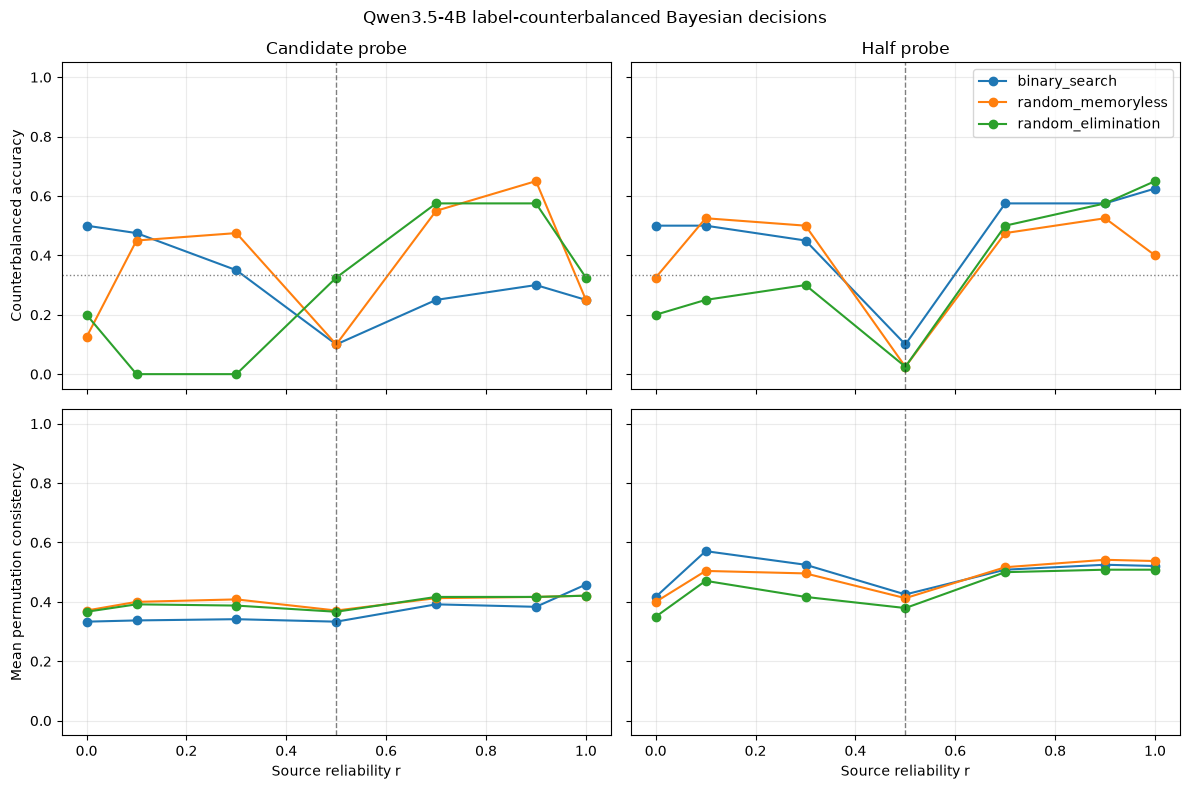

In [11]:
def grouped_mean(
    rows: Sequence[dict[str, object]], metric_key: str
) -> dict[tuple[str, str, float], float]:
    grouped: dict[tuple[str, str, float], list[float]] = {}
    for row in rows:
        key = (str(row["policy"]), str(row["probe_kind"]), float(row["reliability"]))
        grouped.setdefault(key, []).append(float(row[metric_key]))
    return {key: sum(values) / len(values) for key, values in grouped.items()}


accuracies = grouped_mean(results, "counterbalanced_correct")
consistencies = grouped_mean(results, "permutation_consistency")
reliability_values = sorted(float(r) for r in RELIABILITIES)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex="col", sharey="row")
for column, probe_kind in enumerate(("candidate", "half")):
    accuracy_axis = axes[0, column]
    consistency_axis = axes[1, column]
    for policy in POLICIES:
        accuracy_values = [
            accuracies.get((policy, probe_kind, reliability), float("nan"))
            for reliability in reliability_values
        ]
        consistency_values = [
            consistencies.get((policy, probe_kind, reliability), float("nan"))
            for reliability in reliability_values
        ]
        accuracy_axis.plot(reliability_values, accuracy_values, marker="o", label=policy)
        consistency_axis.plot(
            reliability_values, consistency_values, marker="o", label=policy
        )
    accuracy_axis.axhline(1 / 3, color="gray", linestyle=":", linewidth=1)
    accuracy_axis.set_title(f"{probe_kind.capitalize()} probe")
    consistency_axis.set_xlabel("Source reliability r")
    for axis in (accuracy_axis, consistency_axis):
        axis.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
        axis.set_ylim(-0.05, 1.05)
        axis.grid(alpha=0.25)
axes[0, 0].set_ylabel("Counterbalanced accuracy")
axes[1, 0].set_ylabel("Mean permutation consistency")
axes[0, 1].legend(loc="best")
fig.suptitle("Qwen3.5-4B label-counterbalanced Bayesian decisions")
fig.tight_layout()
plt.show()

## Recommended next expansion

Before drawing conclusions, sweep all secrets and use enough repeats for stable estimates. Keep transcript wording, seeds, probe meanings, and the six label assignments frozen. The returned exact posterior, full messages, per-permutation label scores, aggregate semantic scores, counterbalanced correctness, and permutation consistency are suitable keys for later activation caching or causal interventions without changing the behavioral task.